In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("facebook_ads_data (2.0).csv")

In [3]:
df['ad_date'] = pd.to_datetime(df['ad_date'])

In [4]:
df['ROMI'] = (df['total_value'] - df['total_spend']) / df['total_spend']

In [5]:
df_2021 = df[df['ad_date'].dt.year == 2021]

In [6]:
daily = df_2021.groupby('ad_date').agg({'total_spend':'sum','ROMI':'mean'}).reset_index()

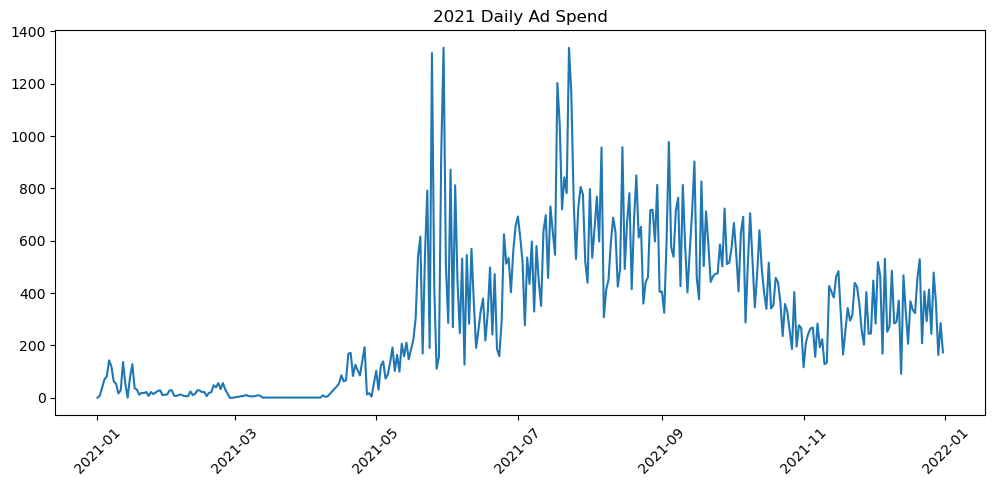

In [7]:
plt.figure(figsize=(12,5))
plt.plot(daily['ad_date'], daily['total_spend'])
plt.xticks(rotation=45)
plt.title("2021 Daily Ad Spend")
plt.show()

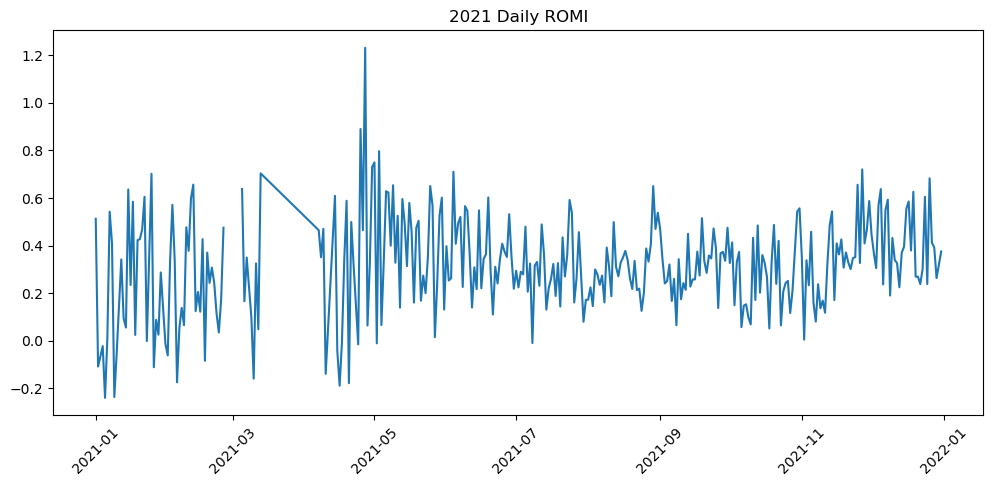

In [8]:
plt.figure(figsize=(12,5))
plt.plot(daily['ad_date'], daily['ROMI'])
plt.xticks(rotation=45)
plt.title("2021 Daily ROMI")
plt.show()

In [9]:
daily['spend_ma'] = daily['total_spend'].rolling(7).mean()
daily['romi_ma'] = daily['ROMI'].rolling(7).mean()

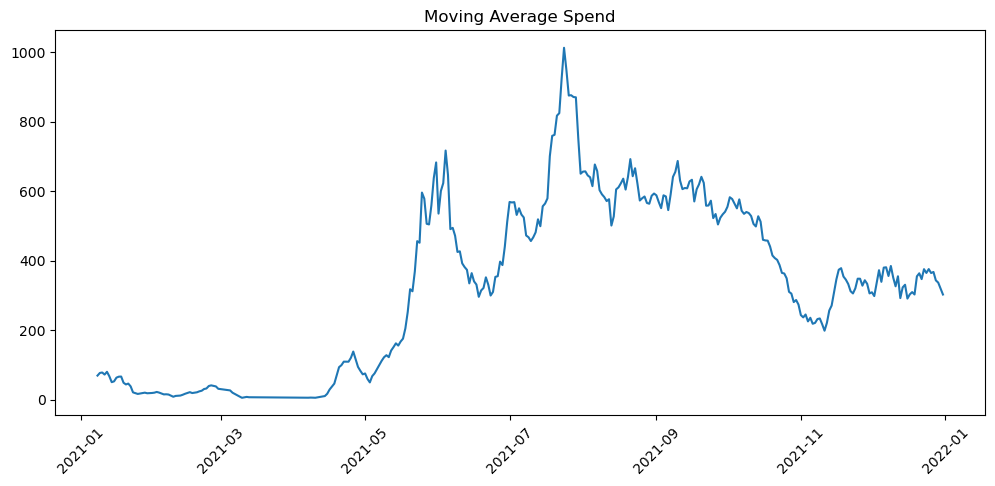

In [10]:
plt.figure(figsize=(12,5))
plt.plot(daily['ad_date'], daily['spend_ma'])
plt.xticks(rotation=45)
plt.title("Moving Average Spend")
plt.show()

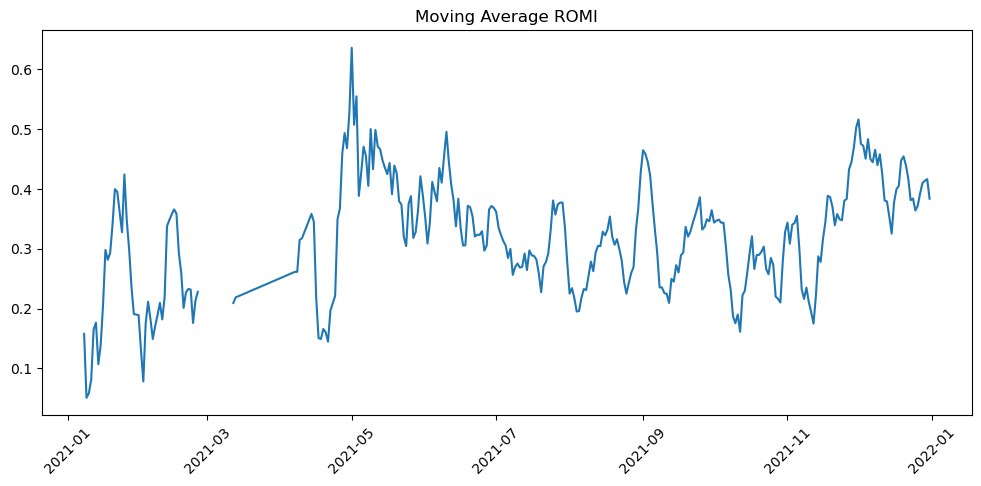

In [11]:
plt.figure(figsize=(12,5))
plt.plot(daily['ad_date'], daily['romi_ma'])
plt.xticks(rotation=45)
plt.title("Moving Average ROMI")
plt.show()

In [12]:
campaign = df.groupby('campaign_name').agg({'total_spend':'sum','total_value':'sum'}).reset_index()

In [13]:
campaign['ROMI'] = (campaign['total_value'] - campaign['total_spend']) / campaign['total_spend']

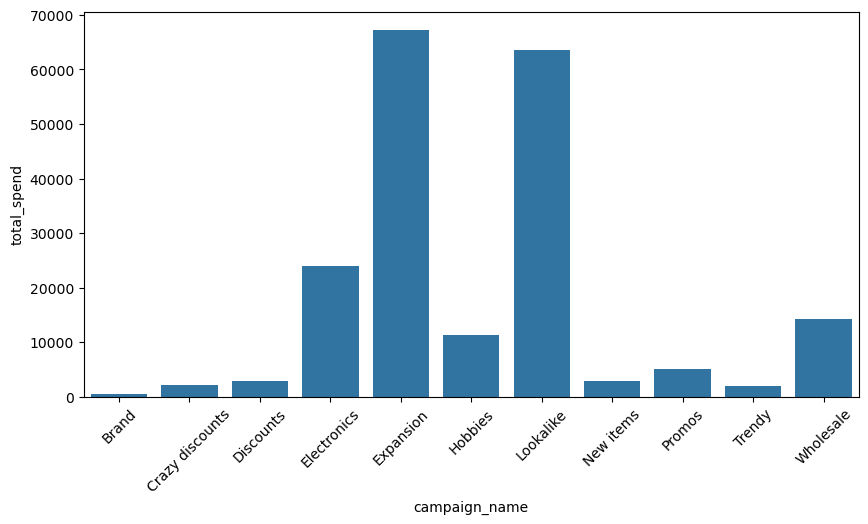

In [14]:
plt.figure(figsize=(10,5))
sns.barplot(data=campaign, x='campaign_name', y='total_spend')
plt.xticks(rotation=45)
plt.show()

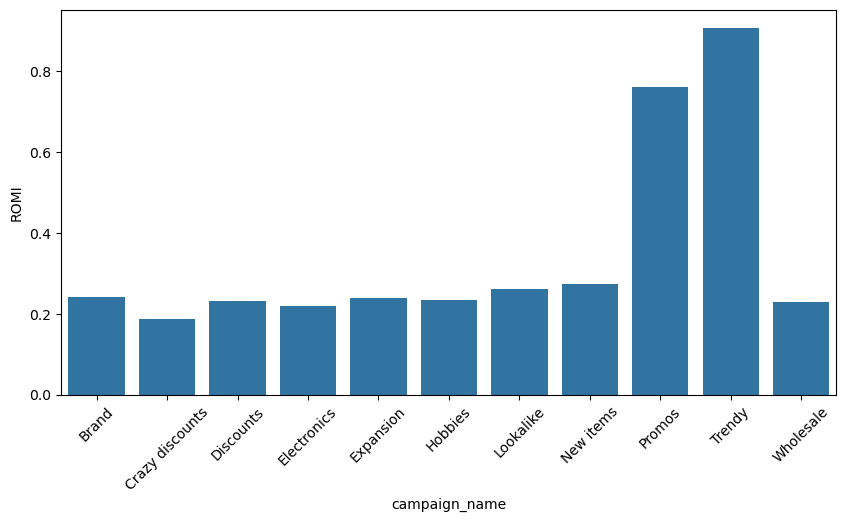

In [15]:
plt.figure(figsize=(10,5))
sns.barplot(data=campaign, x='campaign_name', y='ROMI')
plt.xticks(rotation=45)
plt.show()

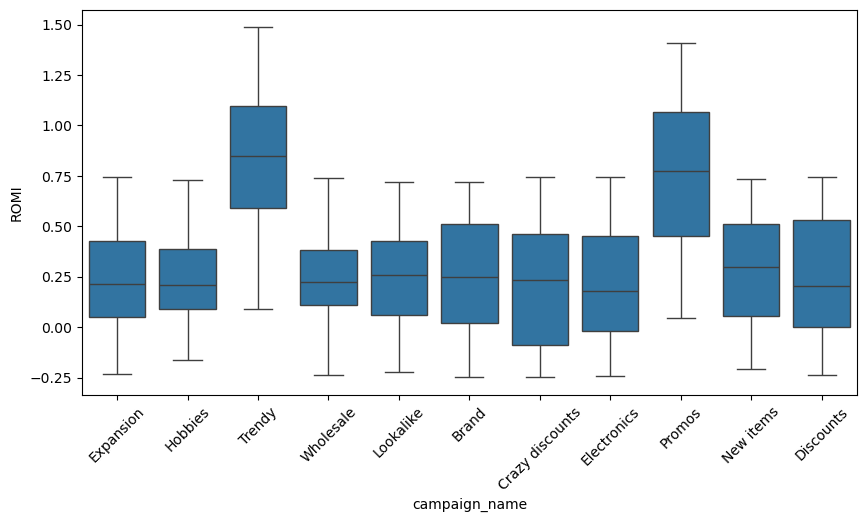

In [16]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='campaign_name', y='ROMI')
plt.xticks(rotation=45)
plt.show()

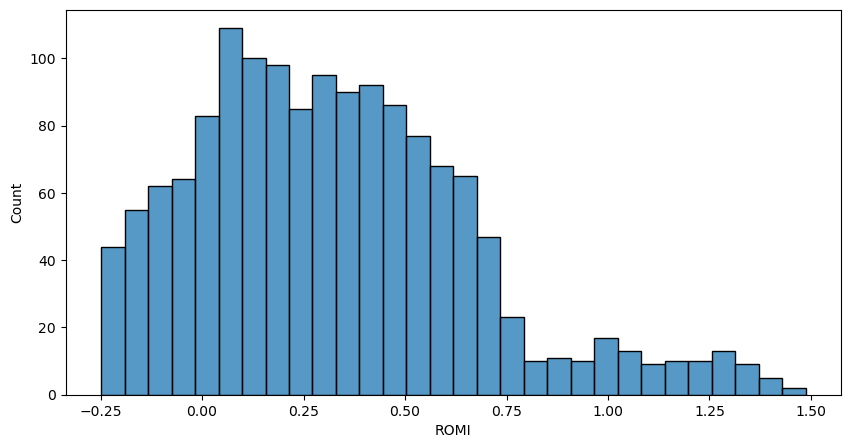

In [17]:
plt.figure(figsize=(10,5))
sns.histplot(df['ROMI'], bins=30)
plt.show()

In [18]:
corr = df.select_dtypes(include=np.number).corr()

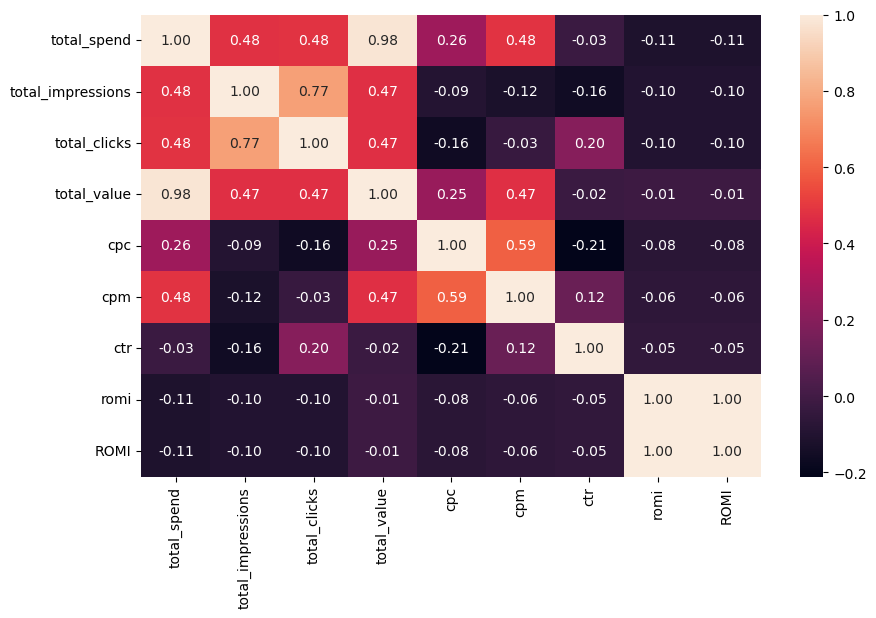

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.show()

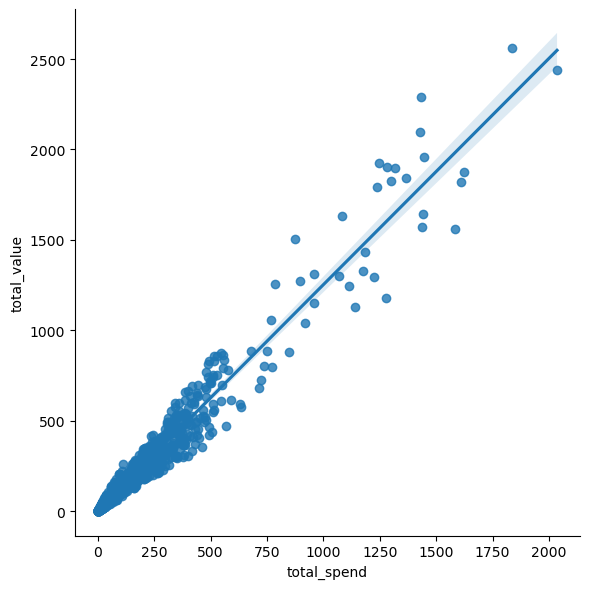

In [20]:
sns.lmplot(data=df, x='total_spend', y='total_value', height=6)
plt.show()